## Does the market overreact to goals?

`regression_analysis.ipynb` found that price movement tracks the actual scoreline much more than underlying performance (xG). This notebook asks the other half of the original question: when the market *does* react to a goal, does it overreact and then partially correct (mean-reversion), or does it keep drifting the same way (momentum/underreaction)?

**Event-study design**: for each goal, split the price reaction of the scoring team's own win-probability market into two pieces:

- **`jump`** = price 4 min after the goal &minus; price 2 min before it. The immediate repricing.
- **`drift`** = price 10 min after the goal &minus; price 4 min after it. What happens next.

If `drift` tends to have the **opposite sign** of `jump`, that's the market giving back part of its initial move &mdash; overreaction. If `drift` tends to have the **same sign**, that's continuation/momentum, or just new information (other events) arriving.

### A methodology note on match time

SofaScore's incident `time` (and `added_time`) is the *nominal* match clock (e.g. minute 60), not real elapsed clock time &mdash; it doesn't account for the ~15 min halftime break, or any break before/during extra time. Checked directly: `time_seconds` on `period` boundary incidents is exactly `time * 60`, confirming there's no break baked in.

That's fine for a single visual overlay (as in `final_match_analysis.ipynb`), but fatal for a windowed, minute-precision study like this one: treating a 60th-minute goal as "60 minutes after kickoff" would look at candles from ~15 minutes *before* the goal actually happened.

**This notebook restricts to first-half goals only** (kickoff is a real, unambiguous anchor with no break in between), and additionally requires the full `[goal - 2 min, goal + 10 min]` window to fit inside the first half (i.e. `t0 + 10 <= 45`), so no window crosses into the unmodeled halftime break. That drops the sample from 308 goals to well under half. Extending to the second half and extra time would need the actual break durations, which aren't in any of the three pulled sources &mdash; noted as follow-up work at the end.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Notebook lives in code/, so data/ and output/ live one level up.
ROOT = Path.cwd().parent
FIG_DIR = ROOT / "output" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEAM_NAME_ALIASES = {
    "Cape Verde": "Cabo Verde",
    "Bosnia and Herzegovina": "Bosnia & Herzegovina",
    "Congo DR": "DR Congo",
    "Ivory Coast": "C\u00f4te d'Ivoire",
    "IR Iran": "Iran",
    "Turkiye": "T\u00fcrkiye",
    "Curacao": "Cura\u00e7ao",
    "Korea Republic": "South Korea",
}
REVERSE_ALIASES = {v: k for k, v in TEAM_NAME_ALIASES.items()}

BEFORE_MIN, SHORT_MIN, LONG_MIN = 2, 4, 10

In [2]:
def price_at(grp: pd.DataFrame, kickoff: pd.Timestamp, target_min: float) -> float:
    target_ts = kickoff + pd.Timedelta(minutes=target_min)
    before = grp[grp["timestamp"] <= target_ts]
    return before["price_close"].iloc[-1] if len(before) else np.nan


def sign_test(df: pd.DataFrame, label: str) -> pd.Series:
    nontrivial = df[df["jump"].abs() > 0.02]
    opposite = ((nontrivial["jump"] > 0) & (nontrivial["drift"] < 0)) | (
        (nontrivial["jump"] < 0) & (nontrivial["drift"] > 0)
    )
    n, k = len(nontrivial), int(opposite.sum())
    p = stats.binomtest(k, n, 0.5).pvalue if n else float("nan")
    print(
        f"[{label}] n={n}, opposite-signed (reversion) = {opposite.mean():.1%}, "
        f"binomial p (vs. 50/50) = {p:.4f}, mean jump = {df['jump'].mean():.3f}, "
        f"mean drift = {df['drift'].mean():+.3f}, corr(jump, drift) = {df['jump'].corr(df['drift']):+.3f}"
    )
    return opposite


def has_followup_goal(event_id, t0) -> bool:
    others = [t for t in all_goal_times.get(event_id, []) if t != t0]
    return any(t0 < t <= t0 + LONG_MIN for t in others)


### Matching each goal to its scoring team's own Kalshi market

Unlike the earlier notebooks (which only needed the *outcome* market), this one needs, for every goal, the specific market pricing *the scoring team's own* win probability &mdash; so a goal always pushes its own market up, regardless of who eventually wins.

Two data quirks turned up while wiring this up:

1. Kalshi's `yes_team_subtitle` is inconsistently formatted &mdash; some rows are `"Argentina"`, others `"Reg Time: Argentina"`. Stripping the `"Reg Time: "` prefix before matching avoids silently dropping half the markets.
2. Own goals: SofaScore's `is_home` flag on a `goal` incident already reflects *whose score increased* (the beneficiary), not the scorer's own team &mdash; confirmed by checking `is_home` against `home_score`/`away_score` on the `ownGoal` rows. So no special-casing is needed; `is_home` can be used directly to find the benefiting team.

In [3]:
markets = pd.read_parquet(ROOT / "data/kalshi/kxwcgame_markets.parquet")
candles = pd.read_parquet(ROOT / "data/kalshi/candlesticks/kxwcgame_minute.parquet")
schedule = pd.read_parquet(ROOT / "data/sofascore/schedule.parquet")
incidents = pd.read_parquet(ROOT / "data/sofascore/incidents.parquet")

parts = markets["event_title"].str.split(" vs ", n=1, expand=True)
markets["team1_kalshi"] = parts[0].str.strip()
markets["team2_kalshi"] = parts[1].str.split(":").str[0].str.strip()
markets["subtitle_clean"] = (
    markets["yes_team_subtitle"].str.replace("Reg Time: ", "", regex=False).str.strip()
)
markets["team_set"] = [
    frozenset(t)
    for t in zip(
        markets["team1_kalshi"].replace(TEAM_NAME_ALIASES),
        markets["team2_kalshi"].replace(TEAM_NAME_ALIASES),
    )
]

sched = schedule.copy()
sched["team_set"] = [frozenset(t) for t in zip(sched["home_team"], sched["away_team"])]

markets_unique = markets[["event_ticker", "team_set"]].drop_duplicates()
before = len(markets_unique)
market_to_event = markets_unique.merge(
    sched[["team_set", "event_id", "start_time"]], on="team_set", how="left"
)
print(f"markets merge sched: {before} rows -> {len(market_to_event)} rows")
print(f"unmatched Kalshi events -> SofaScore event_id: {market_to_event['event_id'].isna().sum()} / {len(market_to_event)}")

goals = incidents[incidents["incident_type"] == "goal"].copy()
before = len(goals)
goals = goals.merge(sched[["event_id", "home_team", "away_team"]], on="event_id", how="left")
print(f"goals merge sched: {before} rows -> {len(goals)} rows")
goals["scoring_team_sofa"] = np.where(goals["is_home"], goals["home_team"], goals["away_team"])
goals["scoring_team_kalshi"] = goals["scoring_team_sofa"].map(lambda x: REVERSE_ALIASES.get(x, x))
before = len(goals)
goals = goals.merge(market_to_event[["event_id", "event_ticker", "start_time"]], on="event_id", how="left")
print(f"goals merge market_to_event: {before} rows -> {len(goals)} rows")

team_ticker_lookup = markets.set_index(["event_ticker", "subtitle_clean"])["market_ticker"].to_dict()
goals["market_ticker"] = [
    team_ticker_lookup.get((et, team)) for et, team in zip(goals["event_ticker"], goals["scoring_team_kalshi"])
]
print(f"goals unmatched to a market_ticker: {goals['market_ticker'].isna().sum()} / {len(goals)}")

markets merge sched: 104 rows -> 104 rows
unmatched Kalshi events -> SofaScore event_id: 0 / 104
goals merge sched: 308 rows -> 308 rows
goals merge market_to_event: 308 rows -> 308 rows
goals unmatched to a market_ticker: 0 / 308


### Extracting the price reaction window for each usable goal

In [4]:
goals["t0"] = goals["time"] + goals["added_time"].fillna(0)
usable_goals = goals[
    (goals["time"] <= 45) & (goals["t0"] >= BEFORE_MIN) & (goals["t0"] + LONG_MIN <= 45)
].copy()
print(f"usable first-half goals: {len(usable_goals)} / {len(goals)} total goals")

candles_by_ticker = {ticker: grp.sort_values("timestamp") for ticker, grp in candles.groupby("market_ticker")}


rows = []
for g in usable_goals.itertuples():
    grp = candles_by_ticker.get(g.market_ticker)
    if grp is None:
        continue
    pre = price_at(grp, g.start_time, g.t0 - BEFORE_MIN)
    short = price_at(grp, g.start_time, g.t0 + SHORT_MIN)
    long_ = price_at(grp, g.start_time, g.t0 + LONG_MIN)
    if any(pd.isna(x) for x in (pre, short, long_)):
        continue
    rows.append(
        {
            "event_id": g.event_id,
            "t0": g.t0,
            "scoring_team": g.scoring_team_sofa,
            "pre": pre,
            "short": short,
            "long": long_,
            "jump": short - pre,
            "drift": long_ - short,
        }
    )

reactions = pd.DataFrame(rows)
print(f"goals with complete price data across the full window: {len(reactions)}")
reactions[["pre", "short", "long", "jump", "drift"]].describe()

usable first-half goals: 84 / 308 total goals
goals with complete price data across the full window: 84


,pre,short,long,jump,drift
count,84.000000,84.000000,84.000000,84.000000,84.000000
mean,0.541667,0.692976,0.692500,0.151310,-0.000476
std,0.292549,0.271190,0.276143,0.080492,0.055751
min,0.010000,0.030000,0.030000,-0.020000,-0.240000
25%,0.250000,0.447500,0.440000,0.100000,-0.010000
50%,0.585000,0.770000,0.790000,0.165000,0.000000
75%,0.815000,0.922500,0.932500,0.212500,0.020000
max,0.990000,0.990000,0.990000,0.300000,0.190000


### Reversion vs. continuation

If the market were overreacting and correcting, `drift` should tend to run opposite `jump`. Comparing the *sign* (not magnitude) of opposite-vs-same-direction drift against the 50/50 baseline is the most direct test here, since drift magnitude is noisy relative to sample size.

Also checked for a confound: a **second goal landing inside the drift window** would itself move price for reasons that have nothing to do with reverting the first goal's jump. Results are reported both with and without those cases.

In [5]:
all_goal_times = goals.groupby("event_id")["t0"].apply(list).to_dict()


reactions["has_followup"] = [has_followup_goal(r.event_id, r.t0) for r in reactions.itertuples()]
print(f"goals with a follow-up goal inside the drift window: {reactions['has_followup'].sum()} / {len(reactions)}\n")

opposite_all = sign_test(reactions, "all usable goals")
opposite_clean = sign_test(reactions[~reactions["has_followup"]], "excluding follow-up-goal confound")

goals with a follow-up goal inside the drift window: 11 / 84

[all usable goals] n=76, opposite-signed (reversion) = 27.6%, binomial p (vs. 50/50) = 0.0001, mean jump = 0.151, mean drift = -0.000, corr(jump, drift) = -0.165
[excluding follow-up-goal confound] n=67, opposite-signed (reversion) = 25.4%, binomial p (vs. 50/50) = 0.0001, mean jump = 0.151, mean drift = +0.006, corr(jump, drift) = -0.219


Saved /Users/katemarine/Documents/wc26-prediction-markets/output/figures/overreaction_scatter.png


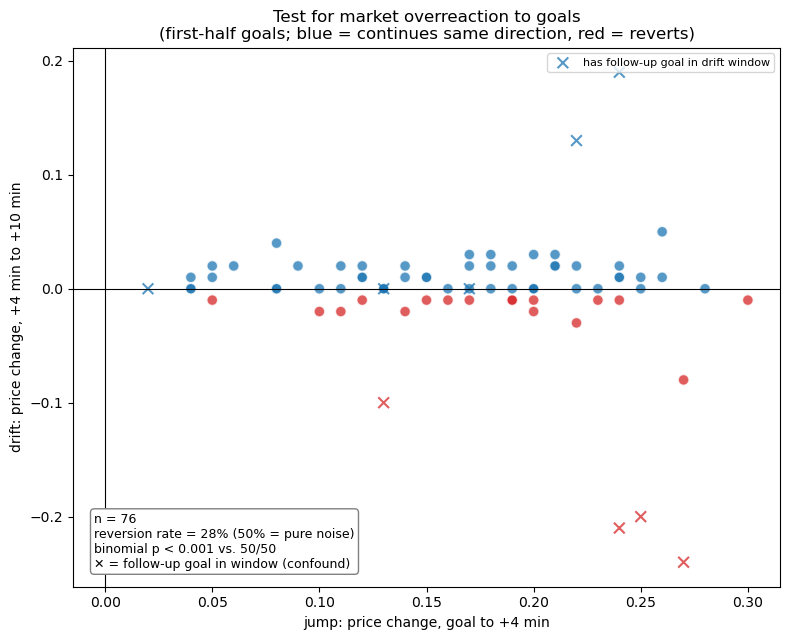

In [6]:
nontrivial = reactions[reactions["jump"].abs() > 0.02].copy()
nontrivial["reversion"] = ((nontrivial["jump"] > 0) & (nontrivial["drift"] < 0)) | (
    (nontrivial["jump"] < 0) & (nontrivial["drift"] > 0)
)

fig, ax = plt.subplots(figsize=(8, 6.5))
for confound, marker in [(False, "o"), (True, "x")]:
    sub = nontrivial[nontrivial["has_followup"] == confound]
    colors = sub["reversion"].map({True: "tab:red", False: "tab:blue"})
    ax.scatter(
        sub["jump"], sub["drift"], c=colors, marker=marker, alpha=0.75, s=60,
        edgecolor="white" if marker == "o" else None,
        label=("has follow-up goal in drift window" if confound else None),
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"jump: price change, goal to +{SHORT_MIN} min")
ax.set_ylabel(f"drift: price change, +{SHORT_MIN} min to +{LONG_MIN} min")
ax.set_title("Test for market overreaction to goals\n(first-half goals; blue = continues same direction, red = reverts)")

n_all, pct_all = len(nontrivial), nontrivial["reversion"].mean()
ax.annotate(
    f"n = {n_all}\nreversion rate = {pct_all:.0%} (50% = pure noise)\n"
    f"binomial p < 0.001 vs. 50/50\n\u2715 = follow-up goal in window (confound)",
    xy=(0.03, 0.03), xycoords="axes fraction", va="bottom", fontsize=9,
    bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "gray"},
)
ax.legend(loc="upper right", fontsize=8)

fig.tight_layout()
out_path = FIG_DIR / "overreaction_scatter.png"
fig.savefig(out_path, dpi=150)
print(f"Saved {out_path}")

### Results so far

No evidence of overreaction. If anything, the opposite: after a goal, price is significantly *more* likely to keep drifting in the same direction over the next several minutes than to give any of it back &mdash; opposite-signed (reverting) drift shows up in only ~25-28% of goals with a real jump, versus the 50% you'd expect from pure noise (binomial p < 0.001), and this holds up even after removing goals that had a second goal land inside the drift window. The average *magnitude* of drift is close to zero and not statistically distinguishable from it (a plain mean test on signed drift is not significant) &mdash; so the continuation pattern is real in direction, but small and noisy in size.

Read together with `regression_analysis.ipynb`: the market reacts to goals roughly in line with (or slightly underreacting to, given the mild continuation) the news, not overreacting and correcting.

**Limitations / next steps:**

- First-half-only restriction cuts the usable sample to 84 of 308 goals (76 with a non-trivial jump). Reconstructing real elapsed time for the second half and extra time (actual halftime/break durations aren't in any pulled source) would unlock the rest.
- Window sizes (2 / 4 / 10 min) were picked to balance sample size against giving `drift` room to show something &mdash; worth a sensitivity check across a few window choices before treating the magnitude (not just the sign) as reliable.
- This only looks at goals. Red cards and VAR overturns are other high-information events in `incidents.parquet` that would extend this same event-study design.